Import Libraries

In [18]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings 
warnings.filterwarnings('ignore')

#load dataset
df = pd.read_csv(r"C:\Users\HP\Desktop\Retail-Sales-Dashboard\data\Sample - Superstore.csv", encoding='latin-1')

print("Shape of the dataset:", df.shape)
print("\nColumns in the dataset:", df.columns)
print("\nFirst 5 row of the dataset:")
df.head()

Shape of the dataset: (9994, 21)

Columns in the dataset: Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

First 5 row of the dataset:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


Data Cleaning and Analysis


In [19]:
#Data Cleaning
print("Missing Values:")
print(df.isnull().sum()) #finds empty/NaN cells
print("\nDuplicate rows:", df.duplicated().sum()) #finds duplicate rows(exact copies of another row)
df.drop_duplicates(inplace=True) #removes duplicate rows from the dataset and modify the original df directly
print("Duplicates removed, New Shape:", df.shape)

#Data Analysis
df['Order Date'] = pd.to_datetime(df['Order Date']) #convert Order Date to datetime format
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
print("\nDates Converted Successfully!")

print("\nData Types:")
print(df.dtypes)

print("\nBasic Stats:")
df.describe()

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Day'] = df['Order Date'].dt.day
df['Quarter'] = df['Order Date'].dt.quarter

#shipping Duration
df['Shipping Duration'] = (df['Ship Date']-df['Order Date']).dt.days   # ship date minus order date

#Checking for negative or zero sales
print("\nNegative Sales Count:", (df['Sales'] < 0).sum())
print("Negative Profit Count:", (df['Profit'] < 0).sum())
print("Zero Sales Count:", (df['Sales'] == 0).sum())

#Drop unnecessary columns
df.drop(columns = ['Row ID','Order ID','Customer ID','Product ID'],inplace = True, errors = 'ignore')
print("\nunnecessary columns are dropped")

df.reset_index(drop = True,inplace = True)
print(df.shape)
print(df.dtypes)
df.head()

Missing Values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Duplicate rows: 0
Duplicates removed, New Shape: (9994, 21)

Dates Converted Successfully!

Data Types:
Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category           

,Order Date,Ship Date,Ship Mode,Customer Name,Segment,Country,City,State,Postal Code,Region,...,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Day,Quarter,Shipping Duration
0,2016-11-08,2016-11-11,Second Class,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,...,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,8,4,3
1,2016-11-08,2016-11-11,Second Class,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,8,4,3
2,2016-06-12,2016-06-16,Second Class,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,12,2,4
3,2015-10-11,2015-10-18,Standard Class,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,11,4,7
4,2015-10-11,2015-10-18,Standard Class,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,...,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,11,4,7


In [20]:
df.info()  #check for any other obvious null value issues

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Order Date         9994 non-null   datetime64[ns]
 1   Ship Date          9994 non-null   datetime64[ns]
 2   Ship Mode          9994 non-null   object        
 3   Customer Name      9994 non-null   object        
 4   Segment            9994 non-null   object        
 5   Country            9994 non-null   object        
 6   City               9994 non-null   object        
 7   State              9994 non-null   object        
 8   Postal Code        9994 non-null   int64         
 9   Region             9994 non-null   object        
 10  Category           9994 non-null   object        
 11  Sub-Category       9994 non-null   object        
 12  Product Name       9994 non-null   object        
 13  Sales              9994 non-null   float64       
 14  Quantity

**Obseravtions from the above cleaning and analysis**
- 9994 rows, 22 columns- decent sized retail dataset
- no null values, before or after cleaning- clean dataset
- sales, quantity, discount and profit are the main columns-used for analysis
- Row ID, Order ID, Product ID and Customer ID are just identifiers, they are not used for building ML model


Exploratory Data Analysis

In [21]:
print(df.columns.tolist())
print(df.shape)

['Order Date', 'Ship Date', 'Ship Mode', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Year', 'Month', 'Day', 'Quarter', 'Shipping Duration']
(9994, 22)


In [22]:
# Sales by category
# checking which product category is driving most revenue

category_sales = df.groupby('Category')['Sales'].sum().reset_index()
category_sales = category_sales.sort_values('Sales', ascending = False)

fig = px.bar(category_sales, x = 'Category', y = 'Sales', color = 'Category', title = 'Total Sales by Category', text_auto = '.2s')
fig.show()

In [23]:
# Monthly Sales Trend
monthly_sales = df.groupby('Month')['Sales'].sum().reset_index()

fig = px.line(monthly_sales, x = 'Month', y = 'Sales',title ='Monthly Sales Trend', markers = True)
fig.update_xaxes(tickvals = list(range(1,13)), ticktext = ['Jan','Feb','Mar','Apr','May','June','July','Aug','Sep','Oct','Nov','Dec'])
fig.show()

In [24]:
# Profit by Region
region_profit = df.groupby('Region')['Profit'].sum().reset_index()

fig = px.pie(region_profit, names = 'Region', values = 'Profit', hole = 0.3, title = 'Profit by Region')
fig.show()

In [25]:
# Top 10 products 
top_products = df.groupby('Product Name')['Sales'].sum().nlargest(10).reset_index()

fig = px.bar(top_products, x = 'Sales', y = 'Product Name', orientation = 'h',title = 'Top 10 Products')
fig.update_layout(yaxis = {'categoryorder':'total ascending'})
fig.show()


In [26]:
# Discount va Profit
fig = px.scatter(df, x = 'Discount', y = 'Profit',color = 'Category', hover_data = ['Sub-Category'],title = 'Discount vs Profit')
fig.add_hline(y = 0, line_dash = 'dash',line_color = 'red', annotation_text = 'Break-even line')
fig.show()

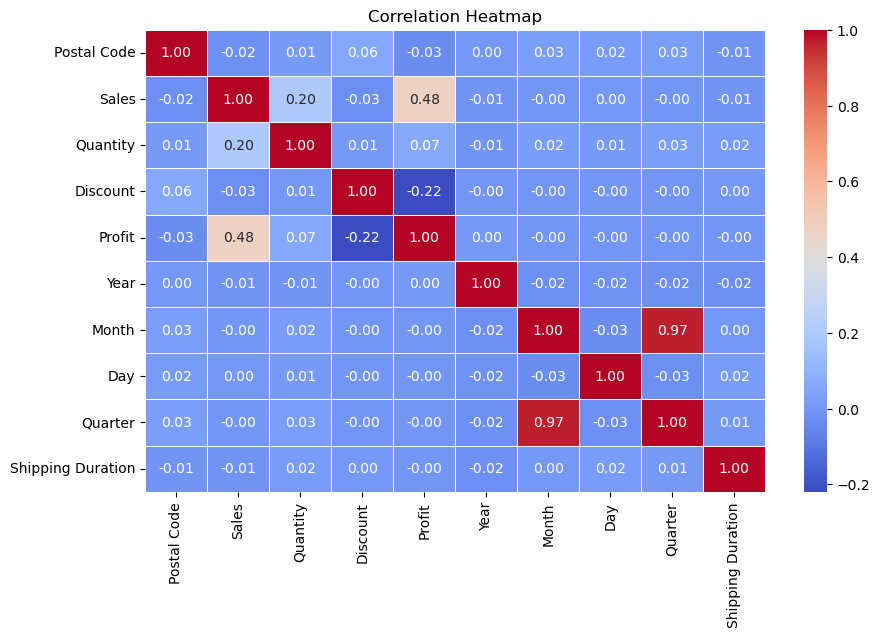

In [27]:
#correlation heatmap
numeric_df = df.select_dtypes(include=np.number) # correlation works only on numbers not text columns
plt.figure(figsize = (10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

Feature Engineering + ML Training

In [28]:
print(df.columns.tolist())
print(df.dtypes)

['Order Date', 'Ship Date', 'Ship Mode', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Year', 'Month', 'Day', 'Quarter', 'Shipping Duration']
Order Date           datetime64[ns]
Ship Date            datetime64[ns]
Ship Mode                    object
Customer Name                object
Segment                      object
Country                      object
City                         object
State                        object
Postal Code                   int64
Region                       object
Category                     object
Sub-Category                 object
Product Name                 object
Sales                       float64
Quantity                      int64
Discount                    float64
Profit                      float64
Year                          int32
Month                         int32
Day                           int32
Quarter        

I'm keeping these features (X):
- segment,region,category, sub-category, ship mode- these are business categorical variables that directly impact the sales
- quantity,discount, profit- numeric
- year, month, quarter, shipping duration-time and logistic features

I'll drop these:
- order date, ship date - already extracted useful information
- customer name, city, state, country, product name - encoding these would create noise, because there are too many unique values
- postal code - just a location identifier
- day - not meaningful for predicting sales

In [29]:
df.drop(columns = ['Order Date', 'Ship Date', 'Customer Name', 'City', 'State','Country', 'Product Name', 'Postal Code', 'Day'], inplace = True, errors = 'ignore')
print("Remaining columns:", df.columns.tolist())
df.head()

Remaining columns: ['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount', 'Profit', 'Year', 'Month', 'Quarter', 'Shipping Duration']


,Ship Mode,Segment,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Year,Month,Quarter,Shipping Duration
0,Second Class,Consumer,South,Furniture,Bookcases,261.9600,2,0.00,41.9136,2016,11,4,3
1,Second Class,Consumer,South,Furniture,Chairs,731.9400,3,0.00,219.5820,2016,11,4,3
2,Second Class,Corporate,West,Office Supplies,Labels,14.6200,2,0.00,6.8714,2016,6,2,4
3,Standard Class,Consumer,South,Furniture,Tables,957.5775,5,0.45,-383.0310,2015,10,4,7
4,Standard Class,Consumer,South,Office Supplies,Storage,22.3680,2,0.20,2.5164,2015,10,4,7


categorical features left after dropping unwanted features are:
- Ship  Mode
- Segment
- Region
- Category
- Sub Category


In [30]:
print(df.shape)

(9994, 13)


In [31]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

categorical_columns = ['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category']

for i in categorical_columns:
    df[i] = le.fit_transform(df[i])
print("Encoding Done, Sample:")
df.head()

Encoding Done, Sample:


,Ship Mode,Segment,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Year,Month,Quarter,Shipping Duration
0,2,0,2,0,4,261.9600,2,0.00,41.9136,2016,11,4,3
1,2,0,2,0,5,731.9400,3,0.00,219.5820,2016,11,4,3
2,2,1,3,1,10,14.6200,2,0.00,6.8714,2016,6,2,4
3,3,0,2,0,16,957.5775,5,0.45,-383.0310,2015,10,4,7
4,3,0,2,1,14,22.3680,2,0.20,2.5164,2015,10,4,7


In [32]:
#defining features and targets
x = df.drop(columns= ['Sales','Profit'])
y = np.log1p(df['Sales']) #sales has extreme outliers, so i'm using log transform to compress that range

print("Features shape:",x.shape)
print("Target shape:", y.shape)

Features shape: (9994, 11)
Target shape: (9994,)


In [33]:
# Train test split
from sklearn.model_selection import train_test_split
#80% training, 20% testing
x_train, x_test, y_train_log, y_test_log = train_test_split(x,y, test_size = 0.2, random_state = 42)
print("Training size:", x_train.shape)
print("Testing size:", y_test_log.shape)

Training size: (7995, 11)
Testing size: (1999,)


In [34]:
# Train models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

#linear regression
model = LinearRegression()
model.fit(x_train,y_train_log)
model_pred = model.predict(x_test)
print("LR done")

#Random forest
mrf = RandomForestRegressor(random_state = 42)
mrf_fit = mrf.fit(x_train,y_train_log)
mrf_pred = mrf.predict(x_test)
print("RF done")

#XGBoost
xgb = XGBRegressor(random_state = 42)
xgb_fit = xgb.fit(x_train,y_train_log)
xgb_pred = xgb.predict(x_test)
print("XGB done")

LR done
RF done
XGB done


In [35]:
#model evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(y_test, pred, model_name):
    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test,pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test,pred)
    print(f"\n{model_name}")
    print(f"MAE : {mae:.2f}")
    print(f"MSE : {mse:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R2 : {r2:.2f}")
evaluate_model(y_test_log, model_pred, "LinearRegression")
evaluate_model(y_test_log, mrf_pred,"RandomForestRegressor")
evaluate_model(y_test_log, xgb_pred, "XGBRegressor")



LinearRegression
MAE : 1.25
MSE : 2.16
RMSE : 1.47
R2 : 0.15

RandomForestRegressor
MAE : 0.85
MSE : 1.19
RMSE : 1.09
R2 : 0.53

XGBRegressor
MAE : 0.84
MSE : 1.17
RMSE : 1.08
R2 : 0.54


**Summary on model evaluation**:

Sales has a wide range, some orders are $14 and some are $22,000, this is kind of skewed distribution and has a lot of outliers, hence tune using log1p tranformer- this compresses the range and makes the distribution normal
- Initially models gave me R2 of 0.19 and plotting sales distribution showed extreme right skewness
- log transform fixed the root cause by improving the R2 to 0.54, which is reasonable and a better chance for model to learn the pattern

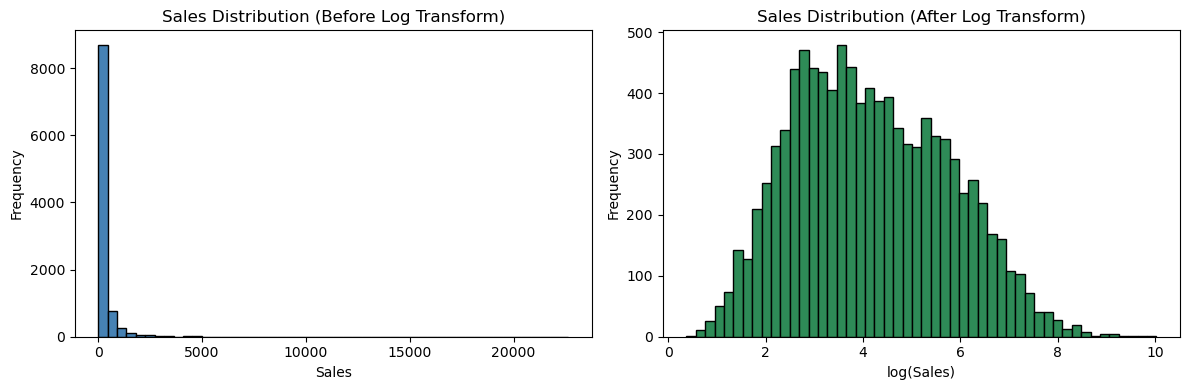

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# before log transform
axes[0].hist(df['Sales'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Sales Distribution (Before Log Transform)')
axes[0].set_xlabel('Sales')
axes[0].set_ylabel('Frequency')

# after log transform
axes[1].hist(np.log1p(df['Sales']), bins=50, color='seagreen', edgecolor='black')
axes[1].set_title('Sales Distribution (After Log Transform)')
axes[1].set_xlabel('log(Sales)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [39]:
import os
import joblib

save_path = r'C:\Users\HP\Desktop\Retail-Sales-Dashboard\models\best_model.pkl'

joblib.dump(xgb, save_path)
print("Model saved at:", save_path)

Model saved at: C:\Users\HP\Desktop\Retail-Sales-Dashboard\models\best_model.pkl
